In [4]:
import pandas as pd
import pyarrow.parquet as pq
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
path = 'Dataset/'
CHUNK_SIZE = 500_000

In [6]:
pf = pq.ParquetFile(path + "SharedResponses_clean.parquet")
total_rows = pf.metadata.num_rows
total_chunks = (total_rows // CHUNK_SIZE) + 1
print(f"Total rows: {total_rows:,} → {total_chunks} chunks of {CHUNK_SIZE:,}")

Total rows: 62,231,803 → 125 chunks of 500,000


In [9]:
survey = (
    pd.read_csv(path + "SharedResponsesSurvey.csv", low_memory=False,
                usecols=['ExtendedSessionID', 'Review_age', 'Review_gender', 'Review_education',
                        'Review_income', 'Review_political', 'Review_religious'])
    .drop_duplicates(subset='ExtendedSessionID')
)
print(f"Survey sessions loaded: {len(survey):,}")

Survey sessions loaded: 492,845


In [10]:
chunks = []
pbar = tqdm(pf.iter_batches(batch_size=CHUNK_SIZE), total=total_chunks, desc="Loading chunks")
try:
    for batch in pbar:
        chunk = batch.to_pandas()
        if isinstance(chunk['ExtendedSessionID'].dtype, pd.CategoricalDtype):
            chunk['ExtendedSessionID'] = chunk['ExtendedSessionID'].astype(str)
        chunk = chunk.merge(survey, on='ExtendedSessionID', how='left')
        chunks.append(chunk)
finally:
    pbar.close()

print("Concatenating chunks...", end=" ", flush=True)
df = pd.concat(chunks, ignore_index=True)
print("done.")  

print(f"\nFinal shape: {df.shape}")
print(f"Rows with survey data: {df['Review_gender'].notna().sum():,} ({df['Review_gender'].notna().mean()*100:.1f}%)")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(df.head())

Loading chunks: 265it [01:27,  3.02it/s]                         

Concatenating chunks... 

done.

Final shape: (62231803, 40)
Rows with survey data: 10,046,584 (16.1%)
Memory usage: 18.08 GB
               ExtendedSessionID  Intervention  PedPed  Barrier  \
0    32757157_6999801415950060.0         False   False    False   
1  -1613944085_422160228641876.0         False    True    False   
2   1425316635_327833569077076.0         False   False     True   
3  -1683127088_785070916172117.0         False    True    False   
4  1525185249_1436495773909467.0         False   False     True   

   CrossingSignal AttributeLevel ScenarioTypeStrict DefaultChoice  \
0               1            Fit            Fitness           Fit   
1               1         Female             Gender          Male   
2               0            Old                Age         Young   
3               2           More        Utilitarian          More   
4               0            Low      Social Status          High   

  NonDefaultChoice  DefaultChoiceIsOmission  ...  FemaleDoctor  MaleDoctor  \
0   

In [11]:
df = df.dropna(axis=0)
df

,ExtendedSessionID,Intervention,PedPed,Barrier,CrossingSignal,AttributeLevel,ScenarioTypeStrict,DefaultChoice,NonDefaultChoice,DefaultChoiceIsOmission,...,FemaleDoctor,MaleDoctor,Dog,Cat,Review_age,Review_education,Review_gender,Review_income,Review_political,Review_religious
4,1525185249_1436495773909467.0,False,False,True,0,Low,Social Status,High,Low,False,...,0,0,0,0,26.0,bachelor,male,5000,0.50,0.50
17,-1033736141_5392791780749771.0,False,False,True,0,Male,Gender,Male,Female,True,...,0,0,0,0,14.0,underHigh,female,default,0.50,0.57
31,-972264246_4277296232223713.0,False,False,True,0,Pets,Species,Hoomans,Pets,False,...,0,0,4,1,20.0,high,male,under5000,0.75,0.84
34,-841718081_3084184331213722.0,False,False,False,2,Pets,Species,Hoomans,Pets,False,...,0,0,2,2,19.0,high,male,default,1.00,0.00
40,1247311683_3858850116393528.0,False,True,False,2,Female,Gender,Male,Female,False,...,2,0,0,0,38.0,others,male,above100000,0.68,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62231755,725752586_6904186263183265.0,True,False,False,0,Pets,Species,Hoomans,Pets,True,...,0,0,4,1,22.0,high,male,35000,0.50,0.00
62231759,1479950156_1327764658273678.0,True,True,False,2,More,Utilitarian,More,Less,False,...,2,0,0,0,40.0,college,male,5000,0.76,0.17
62231764,-1785551894_9617570104574178.0,True,False,False,0,Less,Utilitarian,More,Less,True,...,0,0,0,0,16.0,underHigh,male,default,0.78,0.00
62231773,-671133433_3786068032082825.0,True,True,False,1,Less,Utilitarian,More,Less,True,...,0,0,0,0,20.0,college,male,under5000,0.14,0.19


In [12]:
df_encoded = df.copy()

# Pandas `category` dtype columns → integer codes
pandas_cat_cols = df_encoded.select_dtypes(include='category').columns.tolist()
cat_code_maps = {}

for col in pandas_cat_cols:
    new_col = f"{col}_enc"
    df_encoded[new_col] = df_encoded[col].cat.codes
    cat_code_maps[col] = dict(enumerate(df_encoded[col].cat.categories))
    print(f"  [cat.codes] {col:30s} → {new_col}  "
          f"categories: {list(df_encoded[col].cat.categories)}")

# Ordinal string columns
ordinal_maps = {
    'Review_education': {
        'underhigh':   0,
        'high':        1,
        'vocational':  2,
        'college':     3,
        'bachelor':    4,
        'graduate':    5,
        'others':     -1,
        'default':    -1,
    },
    'Review_income': {
        'under5000':    0,
        '5000':         1,
        '10000':        2,
        'over10000':    3,
        '15000':        4,
        '25000':        5,
        '35000':        6,
        '50000':        7,
        '80000':        8,
        'above100000':  9,
        'default':     -1,
    },
}

for col, mapping in ordinal_maps.items():
    if col not in df_encoded.columns:
        continue
    new_col = f"{col}_enc"
    normalised = df_encoded[col].astype(str).str.strip().str.lower()
    df_encoded[new_col] = normalised.map(mapping).fillna(-1).astype(int)
    n_unmapped = (df_encoded[new_col] == -1).sum()
    print(f"  [ordinal]   {col:30s} → {new_col}  (unmapped rows: {n_unmapped:,})")
    if n_unmapped > 0:
        print(f"              Unseen values: "
              f"{normalised[df_encoded[new_col] == -1].value_counts().head(5).to_dict()}")

# Nominal string columns
nominal_str_cols = ['Review_gender', 'UserCountry3']
label_encoders = {}

for col in nominal_str_cols:
    if col not in df_encoded.columns:
        continue
    new_col = f"{col}_enc"
    series = df_encoded[col].astype(str).str.strip()
    series = series.replace({'': 'MISSING', 'nan': 'MISSING'})
    le = LabelEncoder()
    df_encoded[new_col] = le.fit_transform(series)
    label_encoders[col] = le
    print(f"  [nominal]   {col:30s} → {new_col}  "
          f"({len(le.classes_)} classes: {list(le.classes_[:6])}{'…' if len(le.classes_) > 6 else ''})")

# Clean & standardize continuous numeric features
continuous_cols = ['Review_age', 'Review_political', 'Review_religious']
continuous_cols = [c for c in continuous_cols if c in df_encoded.columns]

valid_ranges = {
    'Review_age':       (0,   120),
    'Review_political': (0.0,   1.0),
    'Review_religious': (0.0,   1.0),
}

if continuous_cols:
    for col in continuous_cols:
        n_inf = np.isinf(df_encoded[col]).sum()
        df_encoded[col] = df_encoded[col].replace([np.inf, -np.inf], np.nan)
        if col in valid_ranges:
            lo, hi = valid_ranges[col]
            n_oob = ((df_encoded[col] < lo) | (df_encoded[col] > hi)).sum()
            df_encoded[col] = df_encoded[col].where(df_encoded[col].between(lo, hi), other=np.nan)
        else:
            n_oob = 0
        median_val = df_encoded[col].median()
        n_nan = df_encoded[col].isna().sum()
        df_encoded[col] = df_encoded[col].fillna(median_val)
        print(f"  [cleaned]   {col:25s}  inf: {n_inf:,}  out-of-range: {n_oob:,}  "
              f"NaN→median({median_val:.4f}): {n_nan:,}")

    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(df_encoded[continuous_cols])
    for i, col in enumerate(continuous_cols):
        df_encoded[f"{col}_scaled"] = scaled_array[:, i]
    print(f"\n  [scaled]    {continuous_cols}  →  _scaled variants (μ≈0, σ≈1)")
    for col, mean, std in zip(continuous_cols, scaler.mean_, scaler.scale_):
        print(f"              {col:25s}  mean={mean:.4f}  std={std:.4f}")

# Drop original categorical columns
cols_to_drop = (
    pandas_cat_cols +
    list(ordinal_maps.keys()) +
    nominal_str_cols +
    continuous_cols
)
cols_to_drop = [c for c in cols_to_drop if c in df_encoded.columns]
df_encoded.drop(columns=cols_to_drop, inplace=True)
print(f"\n  [dropped]   {len(cols_to_drop)} original columns: {cols_to_drop}")

# Summary
enc_cols    = [c for c in df_encoded.columns if c.endswith('_enc')]
scaled_cols = [c for c in df_encoded.columns if c.endswith('_scaled')]

print(f"\n{'─'*60}")
print(f"Original shape   : {df.shape}")
print(f"Final shape      : {df_encoded.shape}")
print(f"New _enc cols    : {enc_cols}")
print(f"New _scaled cols : {scaled_cols}")
print(f"Memory usage     : {df_encoded.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"\n{df_encoded.dtypes}")
print(f"\nEncoded sample:")
print(df_encoded[enc_cols + scaled_cols].head(3).to_string())

  [cat.codes] AttributeLevel                 → AttributeLevel_enc  categories: ['Fat', 'Female', 'Fit', 'High', 'Hoomans', 'Less', 'Low', 'Male', 'More', 'Old', 'Pets', 'Young']
  [cat.codes] ScenarioTypeStrict             → ScenarioTypeStrict_enc  categories: ['Age', 'Fitness', 'Gender', 'Random', 'Social Status', 'Species', 'Utilitarian']
  [cat.codes] DefaultChoice                  → DefaultChoice_enc  categories: ['Fit', 'High', 'Hoomans', 'Male', 'More', 'Young']
  [cat.codes] NonDefaultChoice               → NonDefaultChoice_enc  categories: ['Fat', 'Female', 'Less', 'Low', 'Old', 'Pets']
  [ordinal]   Review_education               → Review_education_enc  (unmapped rows: 817,646)
              Unseen values: {'others': 532830, 'default': 284816}
  [ordinal]   Review_income                  → Review_income_enc  (unmapped rows: 1,493,600)
              Unseen values: {'default': 1493600}
  [nominal]   Review_gender                  → Review_gender_enc  (5 classes: ['apache helicop

In [15]:
df_encoded.to_csv(path + "SharedResponses_combined.csv", index=False)

In [13]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8834024 entries, 4 to 62231784
Data columns (total 40 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   ExtendedSessionID        object 
 1   Intervention             bool   
 2   PedPed                   bool   
 3   Barrier                  bool   
 4   CrossingSignal           uint8  
 5   DefaultChoiceIsOmission  bool   
 6   NumberOfCharacters       uint8  
 7   DiffNumberOFCharacters   int8   
 8   Saved                    bool   
 9   Man                      uint8  
 10  Woman                    uint8  
 11  Pregnant                 uint8  
 12  Stroller                 uint8  
 13  OldMan                   uint8  
 14  OldWoman                 uint8  
 15  Boy                      uint8  
 16  Girl                     uint8  
 17  Homeless                 uint8  
 18  LargeWoman               uint8  
 19  LargeMan                 uint8  
 20  Criminal                 uint8  
 21  MaleExecutiv

In [17]:
df_encoded.head()

,ExtendedSessionID,Intervention,PedPed,Barrier,CrossingSignal,DefaultChoiceIsOmission,NumberOfCharacters,DiffNumberOFCharacters,Saved,Man,...,ScenarioTypeStrict_enc,DefaultChoice_enc,NonDefaultChoice_enc,Review_education_enc,Review_income_enc,Review_gender_enc,UserCountry3_enc,Review_age_scaled,Review_political_scaled,Review_religious_scaled
4,1525185249_1436495773909467.0,False,False,True,0,False,2,0,False,0,...,4,1,3,4,1,3,167,0.160363,-0.404355,0.717880
17,-1033736141_5392791780749771.0,False,False,True,0,True,1,0,False,0,...,2,3,1,0,-1,2,29,-0.964923,-0.404355,0.940279
31,-972264246_4277296232223713.0,False,False,True,0,False,5,0,False,0,...,5,2,5,1,0,3,29,-0.402280,0.530110,1.798104
34,-841718081_3084184331213722.0,False,False,False,2,False,4,0,False,0,...,5,2,5,1,-1,3,29,-0.496054,1.464575,-0.870683
40,1247311683_3858850116393528.0,False,True,False,2,False,2,0,True,0,...,2,3,1,-1,9,3,33,1.285650,0.268459,-0.870683


Character count

In [14]:
df_encoded["count_young"]  = df_encoded["Boy"] + df_encoded["Girl"] + df_encoded["Stroller"]
df_encoded["count_old"]    = df_encoded["OldMan"] + df_encoded["OldWoman"]
df_encoded["count_adult"]  = df_encoded["Man"] + df_encoded["Woman"] + df_encoded["Pregnant"]
df_encoded["count_large"]  = df_encoded["LargeMan"] + df_encoded["LargeWoman"]
df_encoded["count_animal"] = df_encoded["Dog"] + df_encoded["Cat"]
df_encoded["count_human"]  = df_encoded["NumberOfCharacters"] - df_encoded["count_animal"]

df_encoded["diff_lives"]        = df_encoded["DiffNumberOFCharacters"]
df_encoded["diff_human_animal"] = df_encoded["count_human"] - df_encoded["count_animal"]

Age-based features

In [15]:
df_encoded["diff_young"]  = df_encoded["count_young"] - df_encoded["count_old"]
df_encoded["ratio_young"] = df_encoded["count_young"] / (df_encoded["NumberOfCharacters"] + 1e-9)
df_encoded["ratio_old"]   = df_encoded["count_old"]   / (df_encoded["NumberOfCharacters"] + 1e-9)

Gender features

In [16]:
df_encoded["count_male"] = (df_encoded["Man"] + df_encoded["Boy"] + df_encoded["OldMan"] +
                    df_encoded["MaleExecutive"] + df_encoded["MaleAthlete"] + df_encoded["MaleDoctor"] +
                    df_encoded["LargeMan"])

df_encoded["count_female"] = (df_encoded["Woman"] + df_encoded["Girl"] + df_encoded["OldWoman"] +
                      df_encoded["FemaleExecutive"] + df_encoded["FemaleAthlete"] + df_encoded["FemaleDoctor"] +
                      df_encoded["LargeWoman"] + df_encoded["Pregnant"])

df_encoded["diff_gender"] = df_encoded["count_male"] - df_encoded["count_female"]

Social status features

In [17]:
df_encoded["count_high_status"] = (df_encoded["MaleExecutive"] + df_encoded["FemaleExecutive"] +
                           df_encoded["MaleDoctor"]    + df_encoded["FemaleDoctor"] +
                           df_encoded["MaleAthlete"]   + df_encoded["FemaleAthlete"])

df_encoded["count_low_status"]  = df_encoded["Homeless"] + df_encoded["Criminal"]
df_encoded["diff_status"]       = df_encoded["count_high_status"] - df_encoded["count_low_status"]

Scenario level features

In [18]:
df_encoded["is_ped_vs_passenger"] = (df_encoded["PedPed"]).astype(int)
df_encoded["is_omission"]         = df_encoded["DefaultChoiceIsOmission"].astype(int)
df_encoded["intervened"]          = df_encoded["Intervention"].astype(int)
df_encoded["crossing_signal"]     = df_encoded["CrossingSignal"]   # 0=none, 1=green, 2=red
df_encoded["has_barrier"]         = df_encoded["Barrier"].astype(int)

Feature columns

In [19]:
feature_cols = [
    # Trade-off features
    "diff_lives",
    "diff_young",
    "diff_gender",
    "diff_status",
    "diff_human_animal",

    # Count features
    "NumberOfCharacters",
    "count_young",
    "count_old",
    "count_adult",
    "count_large",
    "count_male",
    "count_female",
    "count_high_status",
    "count_low_status",
    "count_animal",
    "count_human",

    # Ratio features
    "ratio_young",
    "ratio_old",

    # Scenario flags
    "is_ped_vs_passenger",
    "is_omission",
    "intervened",
    "crossing_signal",
    "has_barrier",

    # Encoded categoricals
    "Review_gender_enc",
    "Review_education_enc",
    "Review_income_enc",
    "UserCountry3_enc",
    "AttributeLevel_enc",
    "ScenarioTypeStrict_enc",
    "DefaultChoice_enc",
    "NonDefaultChoice_enc",

    # Scaled continuous
    "Review_age_scaled",
    "Review_political_scaled",
    "Review_religious_scaled",
]

X = df_encoded[feature_cols]
y = df_encoded["Saved"]

Hvem er deltakerne?

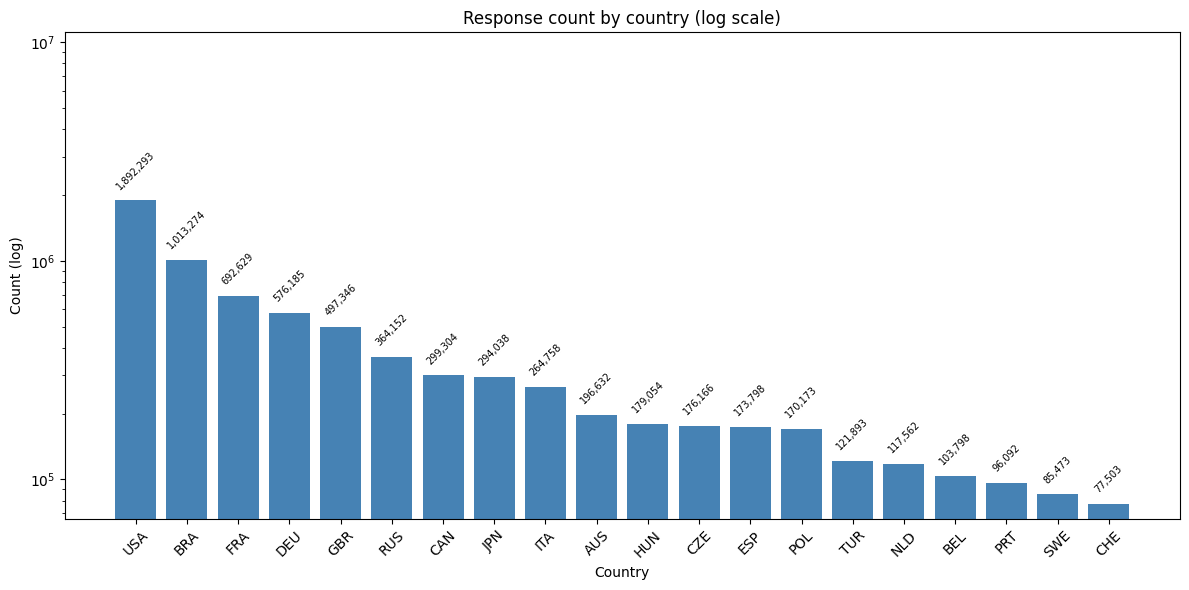

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

country_counts = df["UserCountry3"].value_counts().head(20)

bars = ax.bar(country_counts.index, country_counts.values, color="steelblue")
ax.set_yscale("log")
ax.set_title("Response count by country (log scale)")
ax.set_xlabel("Country")
ax.set_ylabel("Count (log)")
ax.tick_params(axis="x", rotation=45)

# Gi mer plass i toppen
ax.set_ylim(bottom=ax.get_ylim()[0], top=ax.get_ylim()[1] * 5)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.1,
        f"{int(height):,}",
        ha="center", va="bottom", fontsize=7, rotation=45
    )

plt.tight_layout()
plt.show()

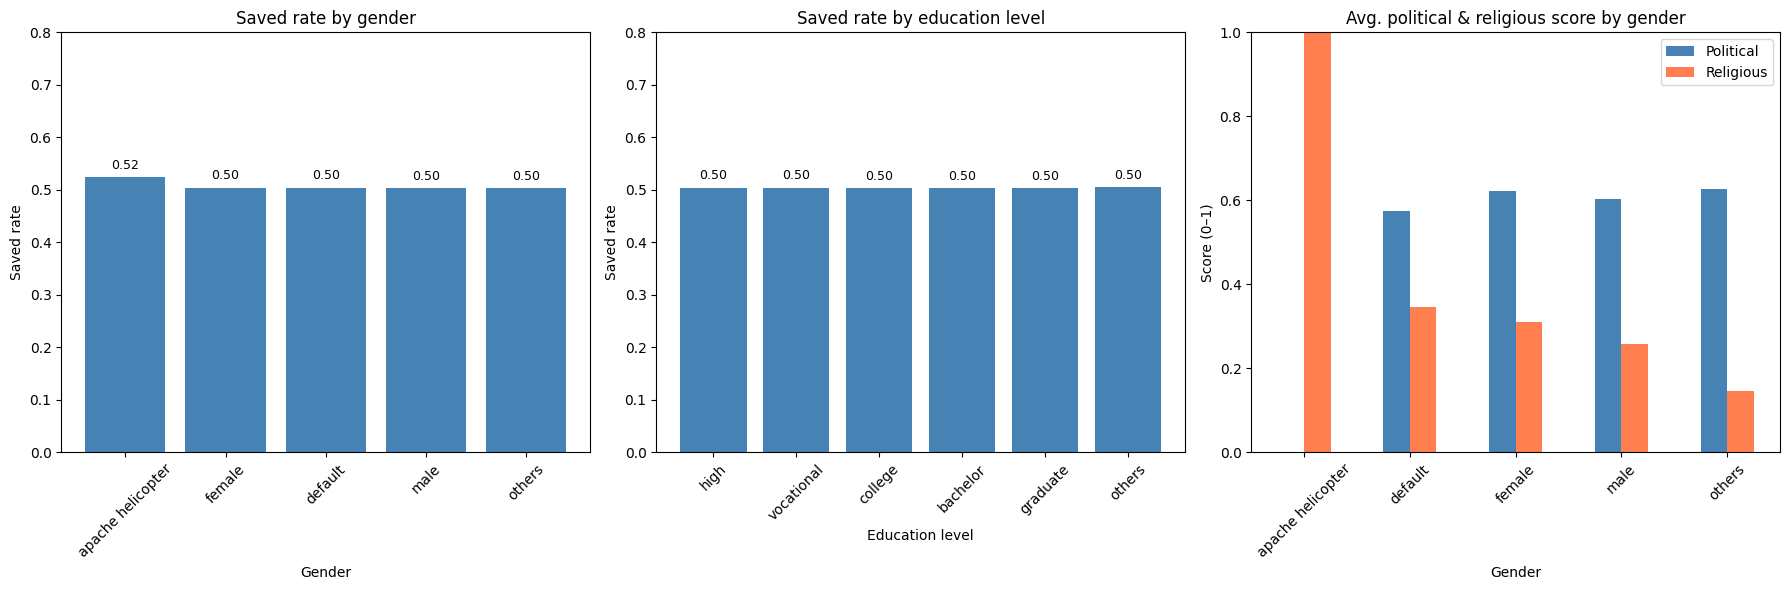

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Saved rate per kjønn
gender_saved = df.groupby("Review_gender")["Saved"].mean().sort_values(ascending=False)
bars1 = axes[0].bar(gender_saved.index, gender_saved.values, color="steelblue")
axes[0].set_title("Saved rate by gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Saved rate")
axes[0].set_ylim(0, 0.8)
axes[0].tick_params(axis="x", rotation=45)
for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}",
        ha="center", va="bottom", fontsize=9
    )

# 2. Saved rate per utdanning
education_order = ["underhigh", "high", "vocational", "college", "bachelor", "graduate", "others"]
edu_saved = df.groupby("Review_education")["Saved"].mean().reindex(education_order).dropna()
bars2 = axes[1].bar(edu_saved.index, edu_saved.values, color="steelblue")
axes[1].set_title("Saved rate by education level")
axes[1].set_xlabel("Education level")
axes[1].set_ylabel("Saved rate")
axes[1].set_ylim(0, 0.8)
axes[1].tick_params(axis="x", rotation=45)
for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}",
        ha="center", va="bottom", fontsize=9
    )

# 3. Gjennomsnittlig politisk og religiøs score per kjønn — mye mer lesbart
demo_means = df.groupby("Review_gender")[["Review_political", "Review_religious"]].mean()
demo_means.plot(kind="bar", ax=axes[2], color=["steelblue", "coral"])
axes[2].set_title("Avg. political & religious score by gender")
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Score (0–1)")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(["Political", "Religious"])

plt.tight_layout()
plt.show()

In [30]:
# Se hvilke verdier som finnes
print(df["Review_gender"].value_counts())

Review_gender
male                 6161711
female               2396772
others                201019
default                74501
apache helicopter         21
Name: count, dtype: int64


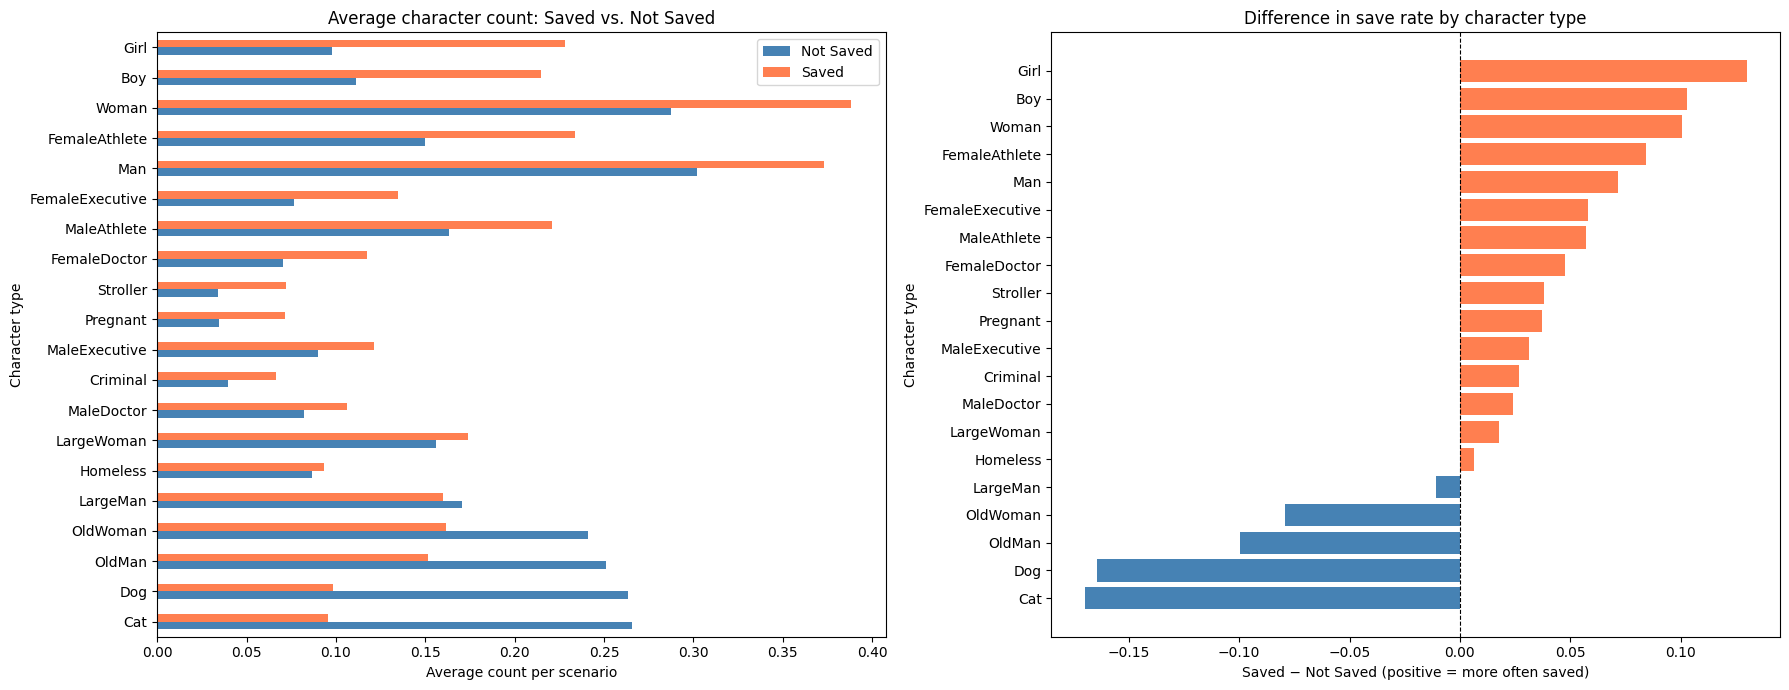

In [67]:
import matplotlib.pyplot as plt

char_cols = [
    "Man", "Woman", "Pregnant", "Stroller", 
    "OldMan", "OldWoman", "Boy", "Girl",
    "Homeless", "Criminal", "LargeMan", "LargeWoman",
    "MaleExecutive", "FemaleExecutive", 
    "MaleAthlete", "FemaleAthlete",
    "MaleDoctor", "FemaleDoctor", 
    "Dog", "Cat"
]

# Gjennomsnittlig antall per karaktertype i reddede vs. ikke reddede scenariet
char_means = df.groupby("Saved")[char_cols].mean().T
char_means.columns = ["Not Saved", "Saved"]

# Sorter etter forskjell mellom saved og not saved
char_means["diff"] = char_means["Saved"] - char_means["Not Saved"]
char_means = char_means.sort_values("diff", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Venstre: Absoluttall
char_means[["Not Saved", "Saved"]].plot(
    kind="barh", ax=axes[0], color=["steelblue", "coral"]
)
axes[0].set_title("Average character count: Saved vs. Not Saved")
axes[0].set_xlabel("Average count per scenario")
axes[0].set_ylabel("Character type")

# Høyre: Differanse (positiv = oftere reddet)
colors = ["coral" if x > 0 else "steelblue" for x in char_means["diff"]]
axes[1].barh(char_means.index, char_means["diff"], color=colors)
axes[1].axvline(x=0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Difference in save rate by character type")
axes[1].set_xlabel("Saved − Not Saved (positive = more often saved)")
axes[1].set_ylabel("Character type")

plt.tight_layout()
plt.show()

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

feature_cols = [
    "diff_lives", "diff_young", "diff_gender", "diff_status", "diff_human_animal",
    "NumberOfCharacters", "count_young", "count_old", "count_adult", "count_large",
    "count_male", "count_female", "count_high_status", "count_low_status",
    "count_animal", "count_human",
    "ratio_young", "ratio_old",
    "is_ped_vs_passenger", "is_omission", "intervened", "crossing_signal", "has_barrier",
    "Review_gender_enc", "Review_education_enc", "Review_income_enc",
    "UserCountry3_enc", "AttributeLevel_enc", "ScenarioTypeStrict_enc",
    "DefaultChoice_enc", "NonDefaultChoice_enc",
    "Review_age_scaled", "Review_political_scaled", "Review_religious_scaled",
]


X = df_encoded[feature_cols]
y = df_encoded["Saved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} rader")
print(f"Test:  {len(X_test):,} rader")

Train: 7,067,219 rader
Test:  1,766,805 rader


In [71]:
lr = LogisticRegression(
    max_iter=10000,
    solver="saga",
    tol=1e-3,         # litt løsere toleranse for raskere konvergens
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [72]:
results = pd.DataFrame({
    "Model":     ["Logistic Regression", "Random Forest"],
    "Accuracy":  [accuracy_score(y_test, y_pred_lr),  accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    "Recall":    [recall_score(y_test, y_pred_lr),    recall_score(y_test, y_pred_rf)],
    "F1-Score":  [f1_score(y_test, y_pred_lr),        f1_score(y_test, y_pred_rf)],
})
print(results.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.6708     0.6698  0.6836    0.6766
      Random Forest    0.7445     0.7452  0.7491    0.7471


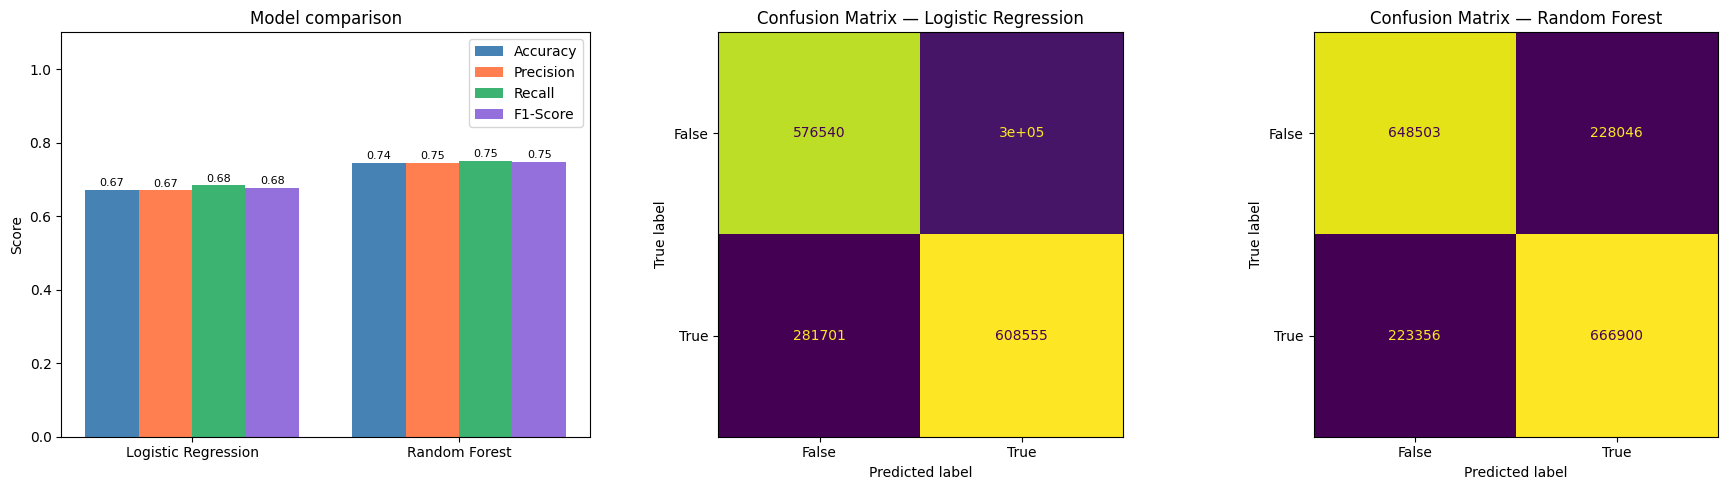

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1 — Sammenlign metrikker
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors  = ["steelblue", "coral", "mediumseagreen", "mediumpurple"]
x = np.arange(len(results["Model"]))
width = 0.2

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = axes[0].bar(x + i * width, results[metric], width, label=metric, color=color)
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     height + 0.005, f"{height:.2f}",
                     ha="center", va="bottom", fontsize=8)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(results["Model"])
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Model comparison")
axes[0].set_ylabel("Score")
axes[0].legend()

# Subplot 2 — Confusion matrix Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[1], colorbar=False
)
axes[1].set_title("Confusion Matrix — Logistic Regression")

# Subplot 3 — Confusion matrix Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=axes[2], colorbar=False
)
axes[2].set_title("Confusion Matrix — Random Forest")

plt.tight_layout()
plt.show()

In [62]:
# Print classification report
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

# Print sammenligningstabellen
print("=== Model Comparison ===")
print(results.round(4).to_string(index=False))

=== Logistic Regression ===
              precision    recall  f1-score   support

       False       0.67      0.66      0.67    496389
        True       0.67      0.68      0.68    503611

    accuracy                           0.67   1000000
   macro avg       0.67      0.67      0.67   1000000
weighted avg       0.67      0.67      0.67   1000000

=== Random Forest ===
              precision    recall  f1-score   support

       False       0.75      0.74      0.74    496389
        True       0.74      0.75      0.75    503611

    accuracy                           0.75   1000000
   macro avg       0.75      0.75      0.75   1000000
weighted avg       0.75      0.75      0.75   1000000

=== Model Comparison ===
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.6719     0.6706  0.6847    0.6776
      Random Forest    0.7454     0.7446  0.7526    0.7486


Step Step 6: Aggregation & Clustering Analysis
Tasks:
• Aggregate decision data by demographic groups (e.g., country, gender, age group).
• Apply clustering techniques (e.g., K-means or hierarchical clustering) to identify
groups with similar moral preferences.
• Use dimensionality reduction techniques (e.g., PCA or t-SNE) for visualizing the clusters.

In [63]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Aggreger moralske preferanser per land
country_profile = df_encoded.groupby("UserCountry3_enc").agg(
    n_responses        = ("Saved", "count"),
    saved_rate         = ("Saved", "mean"),
    intervention_rate  = ("Intervention", "mean"),
    avg_diff_lives     = ("DiffNumberOFCharacters", "mean"),
    pct_ped_vs_pass    = ("PedPed", "mean"),
    avg_political      = ("Review_political_scaled", "mean"),
    avg_religious      = ("Review_religious_scaled", "mean"),
    avg_age            = ("Review_age_scaled", "mean"),
    saved_young        = ("count_young", "mean"),
    saved_old          = ("count_old", "mean"),
    saved_high_status  = ("count_high_status", "mean"),
    saved_low_status   = ("count_low_status", "mean"),
    saved_female       = ("count_female", "mean"),
    saved_male         = ("count_male", "mean"),
    saved_animal       = ("count_animal", "mean"),
).reset_index()

# Behold kun land med nok responser (minst 10,000)
country_profile = country_profile[country_profile["n_responses"] >= 10_000]
print(f"Land inkludert: {len(country_profile)}")

Land inkludert: 56


In [64]:
cluster_features = [
    "saved_rate", "intervention_rate", "avg_diff_lives",
    "pct_ped_vs_pass", "avg_political", "avg_religious",
    "avg_age", "saved_young", "saved_old",
    "saved_high_status", "saved_low_status",
    "saved_female", "saved_male", "saved_animal"
]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(country_profile[cluster_features])

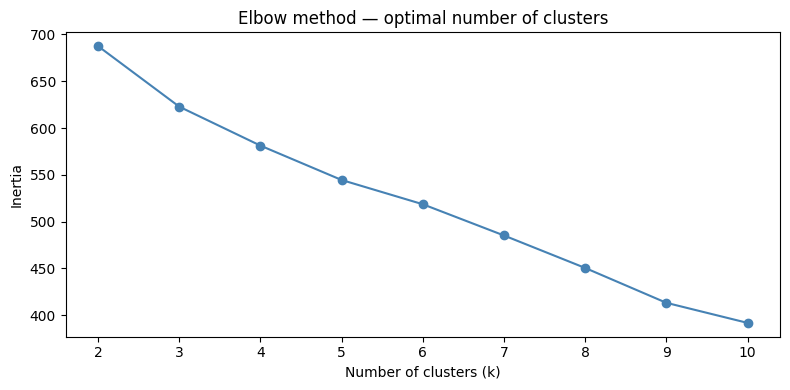

In [65]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertias, marker="o", color="steelblue")
ax.set_title("Elbow method — optimal number of clusters")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia")
plt.tight_layout()
plt.show()

In [52]:
# Velg k basert på elbow plot (f.eks. 4)
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
country_profile["cluster"] = km.fit_predict(X_cluster)

print(country_profile.groupby("cluster")["UserCountry3_enc"].apply(list))

cluster
0    [7, 8, 12, 29, 33, 42, 49, 63, 67, 76, 82, 84,...
1                                   [36, 87, 139, 211]
2    [13, 16, 21, 25, 34, 35, 50, 53, 58, 59, 61, 8...
3                                      [155, 169, 208]
Name: UserCountry3_enc, dtype: object
